In [ ]:
!pip install yfinance
!pip install mplfinance
!pip install MetaTrader5

In [41]:
import MetaTrader5 as mt5
import pandas as pd

# --- Configuración ---
SYMBOL = "EURUSD"
TIMEFRAME = mt5.TIMEFRAME_M5    # 5 minutos
N_BARS = 500                    # número de velas a traer
DATE = pd.Timestamp("2025-09-11")  # día que quieres analizar

# --- 1) Inicializar conexión con MT5 ---
if not mt5.initialize():
    raise RuntimeError(f"Error inicializando MT5: {mt5.last_error()}")

# --- 2) Descargar datos de 5 minutos ---
# Pedimos un rango desde la medianoche hasta el final del día
from datetime import datetime, timedelta

utc_from = datetime(DATE.year, DATE.month, DATE.day, 0, 0)
utc_to   = datetime(DATE.year, DATE.month, DATE.day, 23, 59)

rates = mt5.copy_rates_range(SYMBOL, TIMEFRAME, utc_from, utc_to)
mt5.shutdown()

# --- 3) Convertir a DataFrame ---
if rates is None or len(rates) == 0:
    raise RuntimeError("No se pudieron descargar velas (¿mercado cerrado o símbolo incorrecto?).")

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s', utc=True)
df = df.set_index('time').tz_convert("America/New_York")


# Renombrar columnas como OHLCV
df = df.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "tick_volume": "Volume"
})[["Open","High","Low","Close","Volume"]]

print(df.head())
print(f"Filas en {DATE.date()}: {len(df)}")


                              Open     High      Low    Close  Volume
time                                                                 
2025-09-11 01:00:00-04:00  1.16967  1.16974  1.16960  1.16967     168
2025-09-11 01:05:00-04:00  1.16967  1.16982  1.16961  1.16979     130
2025-09-11 01:10:00-04:00  1.16979  1.16981  1.16967  1.16978     157
2025-09-11 01:15:00-04:00  1.16978  1.16978  1.16959  1.16959      99
2025-09-11 01:20:00-04:00  1.16959  1.16960  1.16929  1.16940     159
Filas en 2025-09-11: 288


In [42]:
# Convertir el índice a datetime (ya lo tienes en df.index)
df_range = df.between_time("05:00", "08:00")

print(df_range.head())
print(f"Filas entre 05:00 y 08:00 del {DATE.date()}: {len(df_range)}")


                              Open     High      Low    Close  Volume
time                                                                 
2025-09-11 05:00:00-04:00  1.16893  1.16900  1.16860  1.16883     387
2025-09-11 05:05:00-04:00  1.16883  1.16945  1.16871  1.16943     294
2025-09-11 05:10:00-04:00  1.16944  1.16962  1.16860  1.16861     428
2025-09-11 05:15:00-04:00  1.16861  1.16879  1.16831  1.16872     327
2025-09-11 05:20:00-04:00  1.16872  1.16926  1.16871  1.16925     279
Filas entre 05:00 y 08:00 del 2025-09-11: 37


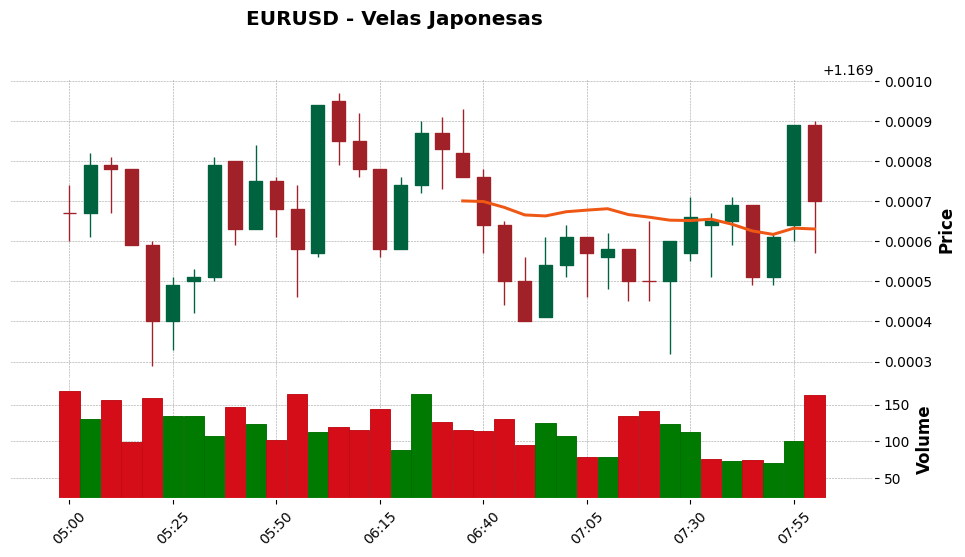

In [35]:
import mplfinance as mpf

# Graficar el DataFrame df en velas japonesas
mpf.plot(df_range, type='candle', style='charles', title='EURUSD - Velas Japonesas', volume=True, mav=(20,50), figsize=(12,6))

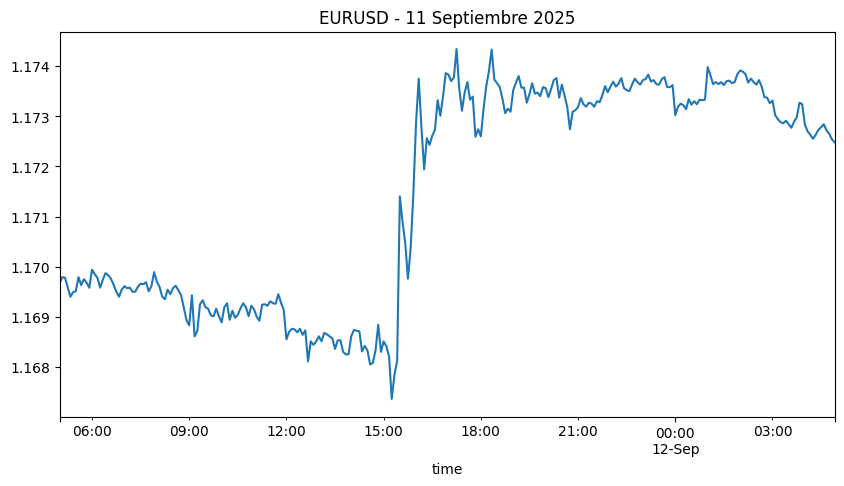

In [26]:
df["Close"].plot(title="EURUSD - 11 Septiembre 2025", figsize=(10,5))
plt.show()

In [24]:
import numpy as np

df["ret"] = np.log(df["Close"]).diff()
rets = df["ret"].dropna()

print(rets.describe())


count    287.000000
mean       0.000008
std        0.000285
min       -0.000835
25%       -0.000094
50%       -0.000009
75%        0.000094
max        0.002804
Name: ret, dtype: float64


In [25]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# ADF
adf_stat, adf_p, *_ = adfuller(rets)
print(f"ADF: stat={adf_stat:.4f}, p={adf_p:.4g}")

# Ljung-Box
print(acorr_ljungbox(rets, lags=[12], return_df=True))

# Normalidad
jb_stat, jb_p = stats.jarque_bera(rets)
print(f"Jarque-Bera: stat={jb_stat:.4f}, p={jb_p:.4g}")


ModuleNotFoundError: No module named 'statsmodels'

In [16]:
import os
import warnings
warnings.filterwarnings('ignore')

# Librerías adicionales para modelos cuantitativos
try:
    from arch import arch_model
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.tsa.stattools import adfuller
    ADVANCED_MODELS = True
except ImportError:
    print("Librerías avanzadas no disponibles. Instala: pip install arch statsmodels")
    ADVANCED_MODELS = False

try:
    from scipy import stats
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("Scipy no disponible para tests estadísticos avanzados")

Librerías avanzadas no disponibles. Instala: pip install arch statsmodels


Aviso: yfinance falló (RuntimeError): No se encontraron columnas OHLCV estándar tras normalizar.
                               Open      High       Low     Close  Volume
Datetime                                                                 
2025-09-11 00:15:00-05:00  1.106109  1.106909  1.105309  1.106209    1059
2025-09-11 01:15:00-05:00  1.105284  1.106084  1.104484  1.105384    1036
2025-09-11 02:15:00-05:00  1.104962  1.105762  1.104162  1.105062    1009
2025-09-11 03:15:00-05:00  1.105375  1.106175  1.104575  1.105475    1091
2025-09-11 04:15:00-05:00  1.104811  1.105611  1.104011  1.104911    1013
Filas 5m en 2025-09-11: 24

=== Descriptivos (ret 5m) ===
count    23.000000
mean     -0.000185
std       0.000627
min      -0.001313
25%      -0.000581
50%      -0.000194
75%       0.000221
max       0.001340
Name: ret, dtype: float64
Skew=0.2777 | Kurtosis(exceso)=0.4558

=== Estadísticos descriptivos (ret) ===
count    23.000000
mean     -0.000185
std       0.000627
min      -0.0

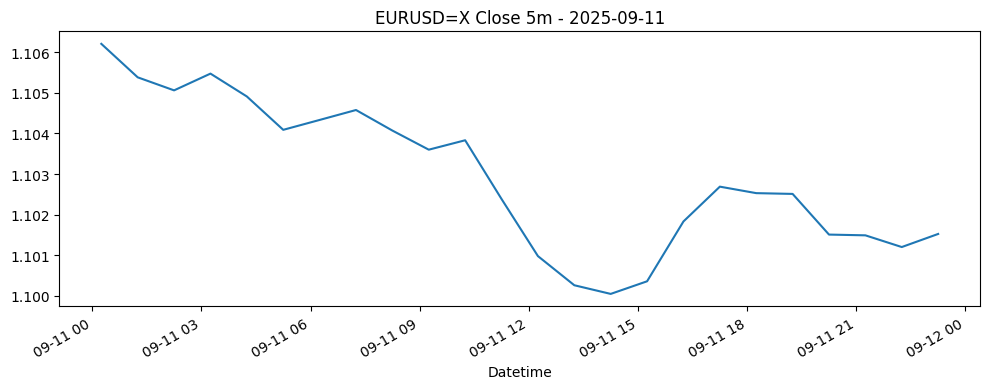

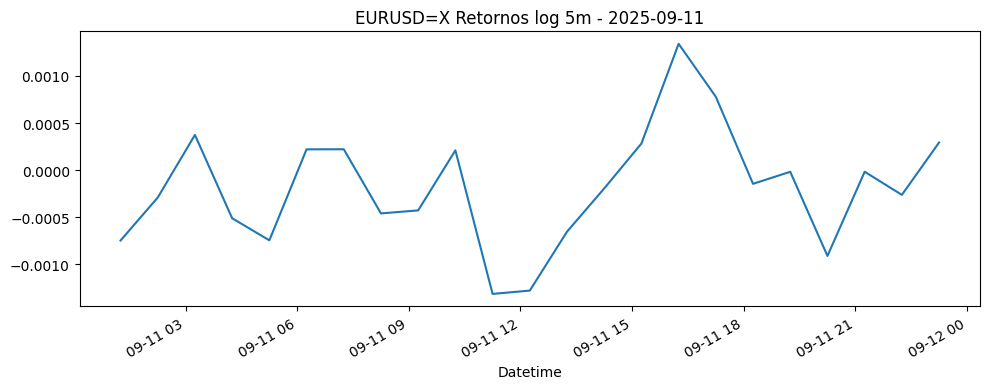

In [18]:
# --- Re-descarga a 5 minutos y filtra el 11/09/2025 ---
INTERVAL = "5m"
PERIOD   = "7d"              # 5m permite hasta ~60d; 7d es suficiente
ANALYSIS_DATE = "2025-09-11" # día a analizar

df_5m = load_data(SYMBOL, PERIOD, INTERVAL, LOCAL_TZ, CSV_PATH)

# Quedarse solo con el día requerido (en tu zona horaria)
df_d = df_5m.loc[ANALYSIS_DATE].copy()
if df_d.empty:
    raise RuntimeError(f"No hay datos 5m para {ANALYSIS_DATE}. "
                       "Prueba con PERIOD='14d' o verifica el símbolo/mercado.")

print(df_d.head().to_string())
print(f"Filas 5m en {ANALYSIS_DATE}: {len(df_d)}")

# --- Retornos y tests como antes ---
import numpy as np

df_d["ret"] = np.log(df_d["Close"]).diff()
rets = df_d["ret"].dropna()

print("\n=== Descriptivos (ret 5m) ===")
print(rets.describe())
print(f"Skew={rets.skew():.4f} | Kurtosis(exceso)={rets.kurtosis():.4f}")

# ADF / Ljung-Box / ARIMA / GARCH se reaprovechan de tu pipeline previo:
safe_print_stat_tests(rets)  # usa la función que ya te pasé

# ARIMA rápido (si statsmodels disponible)
arima_res = None
if ADVANCED_MODELS and len(rets) > 20:
    from statsmodels.tsa.arima.model import ARIMA
    best_bic, best_order = np.inf, None
    for p in range(0, 3):
        for q in range(0, 3):
            try:
                fit = ARIMA(rets, order=(p,0,q)).fit(method_kwargs={"warn_convergence": False})
                if fit.bic < best_bic:
                    best_bic, best_order, arima_res = fit.bic, (p,0,q), fit
            except Exception:
                pass
    if arima_res:
        print(f"\nMejor ARIMA{best_order} (5m) BIC={best_bic:.2f}")
        print(arima_res.summary())

# GARCH(1,1) (si arch disponible)
garch_res = None
if ADVANCED_MODELS and 'arch_model' in globals() and len(rets) > 50:
    from arch import arch_model
    y = rets * 100.0
    try:
        garch_res = arch_model(y, mean='constant', vol='GARCH', p=1, q=1, dist='normal').fit(disp="off")
        print("\nGARCH(1,1) en retornos 5m (%)")
        print(garch_res.summary())
    except Exception as e:
        print(f"GARCH falló: {e}")

# --- Gráficos rápidos ---
import matplotlib.pyplot as plt
df_d["Close"].plot(figsize=(10,4), title=f"{SYMBOL} Close 5m - {ANALYSIS_DATE}")
plt.tight_layout(); plt.show()

rets.plot(figsize=(10,4), title=f"{SYMBOL} Retornos log 5m - {ANALYSIS_DATE}")
plt.tight_layout(); plt.show()


[INFO] Velas día 2025-09-11: 24; retornos disponibles: 23
Price                          Open      High       Low     Close
Ticker                     EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X
Datetime                                                         
2025-09-11 00:00:00-05:00  1.170138  1.170138  1.169317  1.169317
2025-09-11 01:00:00-05:00  1.169317  1.169864  1.168770  1.169317
2025-09-11 02:00:00-05:00  1.169727  1.169864  1.169180  1.169591
2025-09-11 03:00:00-05:00  1.169454  1.169864  1.169317  1.169591
2025-09-11 04:00:00-05:00  1.169591  1.169591  1.168497  1.168907

=== Estadísticos descriptivos (ret) ===
count    23.000000
mean      0.000132
std       0.000788
min      -0.000939
25%      -0.000117
50%       0.000000
75%       0.000234
max       0.002574
Name: ret, dtype: float64
Skew: 2.1820 | Kurtosis (exceso): 5.3725
Shapiro-Wilk: stat=0.7245, p=2.958e-05
Jarque-Bera: stat=31.4206, p=1.503e-07
Tests ADF / Ljung-Box no disponibles (instala statsmodels).

ARIMA omitido (

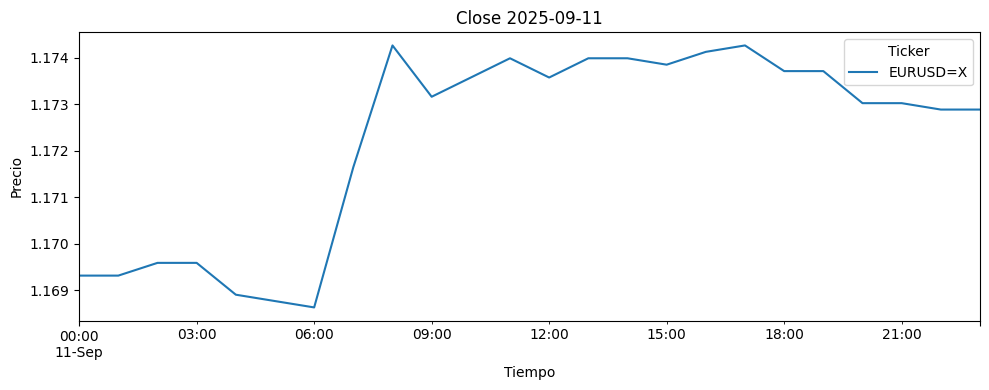

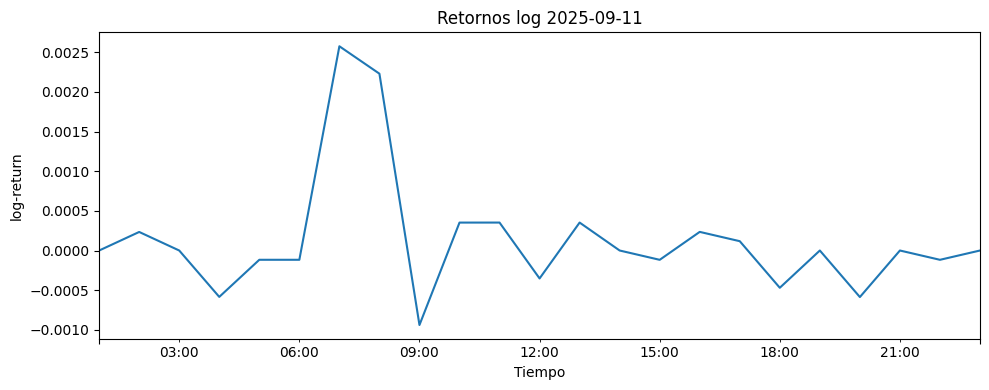

In [17]:
# --- Parámetros del análisis ---
ANALYSIS_DATE = "2025-09-11"        # día a analizar
RET_SCALE = 100.0                   # escalar retornos a % (útil para GARCH)
LB_LAGS = 12                        # lags para Ljung-Box

# --- 1) Filtrar el día ---
df_d = df.loc[ANALYSIS_DATE].copy()
if df_d.empty:
    raise RuntimeError(f"No hay datos para {ANALYSIS_DATE} en el DataFrame.")

# --- 2) Retornos logarítmicos ---
import numpy as np
df_d["ret"] = np.log(df_d["Close"]).diff()
rets = df_d["ret"].dropna()

print(f"[INFO] Velas día {ANALYSIS_DATE}: {len(df_d)}; retornos disponibles: {len(rets)}")
print(df_d[["Open","High","Low","Close"]].head().to_string())

# --- 3) Estadísticos descriptivos y tests ---
def safe_print_stat_tests(series):
    print("\n=== Estadísticos descriptivos (ret) ===")
    print(series.describe())
    print(f"Skew: {series.skew():.4f} | Kurtosis (exceso): {series.kurtosis():.4f}")

    # Normalidad (si SciPy)
    if SCIPY_AVAILABLE:
        try:
            sw_stat, sw_p = stats.shapiro(series.sample(min(5000, len(series)), random_state=42))
            print(f"Shapiro-Wilk: stat={sw_stat:.4f}, p={sw_p:.4g}")
        except Exception as e:
            print(f"Shapiro no disponible ({type(e).__name__}): {e}")
        try:
            jb_stat, jb_p = stats.jarque_bera(series)
            print(f"Jarque-Bera: stat={jb_stat:.4f}, p={jb_p:.4g}")
        except Exception as e:
            print(f"Jarque-Bera no disponible ({type(e).__name__}): {e}")
    else:
        print("Normalidad: SciPy no disponible; se muestran skew/kurtosis como referencia.")

    # ADF (estacionariedad) y Ljung-Box (autocorrelación)
    if ADVANCED_MODELS:
        try:
            adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
            print(f"ADF: stat={adf_stat:.4f}, p={adf_p:.4g}  -> p<0.05 sugiere estacionariedad.")
        except Exception as e:
            print(f"ADF no disponible ({type(e).__name__}): {e}")

        try:
            lb_ret = acorr_ljungbox(series, lags=[LB_LAGS], return_df=True)
            lb_sq  = acorr_ljungbox(series**2, lags=[LB_LAGS], return_df=True)
            print("\nLjung-Box retornos:")
            print(lb_ret.to_string())
            print("\nLjung-Box retornos^2 (heterocedasticidad):")
            print(lb_sq.to_string())
        except Exception as e:
            print(f"Ljung-Box no disponible ({type(e).__name__}): {e}")
    else:
        print("Tests ADF / Ljung-Box no disponibles (instala statsmodels).")

safe_print_stat_tests(rets)

# --- 4) ARIMA rápido (opcional) ---
arima_res = None
if ADVANCED_MODELS and len(rets) > 10:
    print("\n=== Ajuste ARIMA en retornos (d=0) por BIC, p,q ∈ {0..2} ===")
    best_bic, best_order = np.inf, None
    for p in range(0, 3):
        for q in range(0, 3):
            try:
                mdl = ARIMA(rets, order=(p,0,q))
                fit = mdl.fit(method_kwargs={"warn_convergence": False})
                if fit.bic < best_bic:
                    best_bic, best_order, arima_res = fit.bic, (p,0,q), fit
            except Exception:
                pass
    if arima_res is not None:
        print(f"Mejor ARIMA{best_order} BIC={best_bic:.2f}")
        print(arima_res.summary())
    else:
        print("ARIMA no convergió en la cuadrícula probada.")
else:
    print("\nARIMA omitido (no hay statsmodels o pocos datos).")

# --- 5) GARCH(1,1) en retornos (%), muy típico en intradía FX ---
garch_res = None
if ADVANCED_MODELS and 'arch_model' in globals() and len(rets) > 20:
    print("\n=== Ajuste GARCH(1,1) a retornos (%) ===")
    try:
        y = rets * RET_SCALE
        am = arch_model(y, mean='constant', vol='GARCH', p=1, o=0, q=1, dist='normal')
        garch_res = am.fit(disp="off")
        print(garch_res.summary())
    except Exception as e:
        print(f"GARCH falló ({type(e).__name__}): {e}")
else:
    print("\nGARCH omitido (no hay arch o pocos datos).")

# --- 6) Gráficos rápidos ---
import matplotlib.pyplot as plt

# Cierre
ax = df_d["Close"].plot(figsize=(10,4), title=f"Close {ANALYSIS_DATE}")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Precio")
plt.tight_layout()
plt.show()

# Retornos
ax = rets.plot(figsize=(10,4), title=f"Retornos log {ANALYSIS_DATE}")
ax.set_xlabel("Tiempo")
ax.set_ylabel("log-return")
plt.tight_layout()
plt.show()

# Si ajustaste GARCH, gráfica volatilidad condicional
if garch_res is not None:
    cond_vol = garch_res.conditional_volatility  # en unidades de % del RET_SCALE
    ax = cond_vol.plot(figsize=(10,4), title=f"GARCH(1,1) σ_t (en % de retorno) - {ANALYSIS_DATE}")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("σ_t (%)")
    plt.tight_layout()
    plt.show()

# --- 7) (Opcional) Forecast cortito ---
if arima_res is not None:
    try:
        fc = arima_res.get_forecast(steps=3)
        print("\nPronóstico ARIMA (retornos próximos 3 pasos):")
        print(fc.summary_frame())
    except Exception as e:
        print(f"Forecast ARIMA falló ({type(e).__name__}): {e}")

if garch_res is not None:
    try:
        vf = garch_res.forecast(horizon=3)
        # varianza condicional a futuro (en %^2); raíz -> σ en %
        sigma_fut = np.sqrt(vf.variance.values[-1, :])
        print("\nPronóstico GARCH σ (próximos 3 pasos, en %):", sigma_fut)
    except Exception as e:
        print(f"Forecast GARCH falló ({type(e).__name__}): {e}")


## 3) Retiros de liquidez (Maniplulación / Sweeps) y FVGs

**Sweep (liquidity grab):** Cuando una vela rompe un *swing high* o *swing low* previo (barrido de stops) y luego cierra de vuelta dentro del rango, sugiriendo manipulación.

**FVG (Fair Value Gap):** Gap de valor justo (3 velas) donde `High[n-1] < Low[n+1]` en un gap bajista (o `Low[n-1] > High[n+1]` en gap alcista).

In [22]:
def find_swings(data: pd.DataFrame, lookback: int = 3) -> pd.DataFrame:
    """Marca swing highs y lows básicos usando una ventana simétrica."""
    highs = data['High']
    lows = data['Low']
    sh = (highs.shift(1).rolling(lookback, center=True)
          .apply(lambda x: float(x[lookback//2] == max(x)), raw=False))
    sl = (lows.shift(1).rolling(lookback, center=True)
          .apply(lambda x: float(x[lookback//2] == min(x)), raw=False))
    data = data.copy()
    data['SwingHigh'] = sh.fillna(0).astype(bool)
    data['SwingLow']  = sl.fillna(0).astype(bool)
    return data

def detect_sweeps(data: pd.DataFrame, lookback: int = 3) -> pd.DataFrame:
    """Detecta *sweeps* sobre swings recientes: rompe al tick y cierra de vuelta.
    Marca SweepUp (barrido de highs) y SweepDown (barrido de lows).
    """
    d = find_swings(data, lookback)
    d = d.copy()
    d['PrevSwingHigh'] = d['High'].where(d['SwingHigh']).ffill()
    d['PrevSwingLow']  = d['Low'].where(d['SwingLow']).ffill()

    # Up-sweep: hace nuevo máximo por encima del último swing high pero cierra por debajo de ese high
    d['SweepUp'] = (d['High'] > d['PrevSwingHigh']) & (d['Close'] < d['PrevSwingHigh'])
    # Down-sweep: hace nuevo mínimo por debajo del último swing low pero cierra por encima de ese low
    d['SweepDown'] = (d['Low'] < d['PrevSwingLow']) & (d['Close'] > d['PrevSwingLow'])
    return d

def detect_fvg(data: pd.DataFrame) -> pd.DataFrame:
    """Detecta FVGs de 3 velas (alcistas y bajistas)."""
    d = data.copy()
    # FVG alcista: Low[i+1] > High[i-1]
    d['FVG_Up'] = (d['Low'].shift(-1) > d['High'].shift(1))
    # FVG bajista: High[i+1] < Low[i-1]
    d['FVG_Dn'] = (d['High'].shift(-1) < d['Low'].shift(1))
    d['HasFVG'] = d['FVG_Up'] | d['FVG_Dn']
    return d

## 4) Ventanas temporales (Killzones) y etiquetado de eventos
Asignamos si cada barra cae en una ventana relevante (por ejemplo, sesión de NY).

In [23]:
def in_killzone(ts: pd.Timestamp, windows: List[Tuple[str, Tuple[int,int], Tuple[int,int]]]) -> str:
    h, m = ts.hour, ts.minute
    for name, (h1,m1), (h2,m2) in windows:
        t1 = h*60 + m
        tstart = h1*60 + m1
        tend = h2*60 + m2
        if tstart <= t1 <= tend:
            return name
    return "None"

dd = detect_sweeps(df)
dd = detect_fvg(dd)
dd['Killzone'] = [in_killzone(ts, KILLZONES) for ts in dd.index]
dd.head()

,Open,High,Low,Close,Volume,SwingHigh,SwingLow,PrevSwingHigh,PrevSwingLow,SweepUp,SweepDown,FVG_Up,FVG_Dn,HasFVG,Killzone
Datetime,,,,,,,,,,,,,,,
2025-08-25 04:57:00-04:00,1.100497,1.101297,1.099697,1.100597,1064,False,False,NaN,NaN,False,False,False,False,False,None
2025-08-25 05:57:00-04:00,1.100358,1.101158,1.099558,1.100458,1057,False,False,NaN,NaN,False,False,False,False,False,None
2025-08-25 06:57:00-04:00,1.101006,1.101806,1.100206,1.101106,1035,False,True,NaN,1.100206,False,False,True,False,True,None
2025-08-25 07:57:00-04:00,1.102529,1.103329,1.101729,1.102629,1098,False,False,NaN,1.100206,False,False,False,False,False,None
2025-08-25 08:57:00-04:00,1.102295,1.103095,1.101495,1.102395,1060,True,False,1.103095,1.100206,False,False,False,False,False,NY_AM


## 5) Rendimientos logarítmicos y "equilibrio" (intuición ergódica)
Calculamos *log-returns* y definimos una media/centro dinámico (por ejemplo, una media móvil o VWAP) para estudiar reversiones post-manipulación.

In [24]:
def log_returns(data: pd.DataFrame) -> pd.Series:
    px = data['Close']
    return np.log(px/px.shift(1)).fillna(0.0)

dd['logret'] = log_returns(dd)
dd['ma_eq'] = dd['Close'].rolling(50, min_periods=10).mean()  # proxy de equilibrio
dd['dist_eq'] = dd['Close'] - dd['ma_eq']
dd.dropna(inplace=True)
dd.head()

,Open,High,Low,Close,Volume,SwingHigh,SwingLow,PrevSwingHigh,PrevSwingLow,SweepUp,SweepDown,FVG_Up,FVG_Dn,HasFVG,Killzone,logret,ma_eq,dist_eq
Datetime,,,,,,,,,,,,,,,,,,
2025-08-25 13:57:00-04:00,1.104481,1.105281,1.103681,1.104581,1016,False,True,1.104738,1.103681,True,False,False,False,False,NY_PM,0.000491,1.102621,0.001959
2025-08-25 14:57:00-04:00,1.104017,1.104817,1.103217,1.104117,1018,True,False,1.104817,1.103681,False,True,False,False,False,NY_PM,-0.000420,1.102757,0.001360
2025-08-25 15:57:00-04:00,1.103551,1.104351,1.102751,1.103651,1028,False,False,1.104817,1.103681,False,False,False,False,False,None,-0.000422,1.102832,0.000820
2025-08-25 16:57:00-04:00,1.103793,1.104593,1.102993,1.103893,1017,False,True,1.104817,1.102993,False,False,False,True,True,None,0.000219,1.102913,0.000980
2025-08-25 17:57:00-04:00,1.101880,1.102680,1.101080,1.101980,1089,True,False,1.102680,1.102993,False,False,False,True,True,None,-0.001735,1.102847,-0.000867


## 5.1) Modelos Cuantitativos Avanzados: AR-GARCH para FVG Forecasting

Aplicamos modelos autoregresivos y GARCH para:
1. **Modelar la dependencia temporal** en los log-returns
2. **Predecir volatilidad condicional** que puede influir en la formación de FVGs
3. **Identificar regímenes de volatilidad** donde los FVGs son más probables
4. **Cuantificar la persistencia** de los gaps y su probabilidad de cierre

In [25]:
class FVGQuantModel:
    """Modelo cuantitativo para análisis y forecasting de FVGs"""
    
    def __init__(self, data: pd.DataFrame):
        self.data = data.copy()
        self.fitted_models = {}
        self.forecasts = {}
        
    def prepare_features(self):
        """Prepara features cuantitativos para modelar FVGs"""
        d = self.data.copy()
        
        # Volatilidad realizada (rolling)
        d['realized_vol'] = d['logret'].rolling(20).std() * np.sqrt(288)  # para 5min data
        
        # True Range y ATR
        d['tr'] = np.maximum(d['High'] - d['Low'], 
                           np.maximum(abs(d['High'] - d['Close'].shift(1)),
                                    abs(d['Low'] - d['Close'].shift(1))))
        d['atr'] = d['tr'].rolling(14).mean()
        
        # Rango normalizado (gap size potential)
        d['norm_range'] = (d['High'] - d['Low']) / d['Close']
        
        # Momentum features
        d['rsi'] = self._calculate_rsi(d['Close'])
        d['momentum'] = d['Close'].pct_change(20)
        
        # Microstructura proxy
        d['price_impact'] = abs(d['logret']) / d['norm_range']
        d['volume_pressure'] = d.get('Volume', 1) / d['Volume'].rolling(20).mean() if 'Volume' in d.columns else 1
        
        # Distance to equilibrium states
        d['distance_ma50'] = (d['Close'] - d['Close'].rolling(50).mean()) / d['Close']
        d['distance_ma200'] = (d['Close'] - d['Close'].rolling(200).mean()) / d['Close']
        
        return d.dropna()
    
    def _calculate_rsi(self, prices, window=14):
        """Calcula RSI"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    
    def fit_ar_garch(self, series, ar_lags=1, garch_p=1, garch_q=1):
        """Ajusta modelo AR-GARCH a una serie temporal"""
        if not ADVANCED_MODELS:
            return None
            
        try:
            # Test de estacionariedad
            adf_stat, adf_p = adfuller(series.dropna())[:2]
            
            # Modelo AR-GARCH
            model = arch_model(series, vol='GARCH', p=garch_p, q=garch_q, 
                             mean='ARX', lags=ar_lags, rescale=False)
            fitted = model.fit(disp='off')
            
            return {
                'model': fitted,
                'aic': fitted.aic,
                'bic': fitted.bic,
                'adf_statistic': adf_stat,
                'adf_pvalue': adf_p,
                'is_stationary': adf_p < 0.05
            }
        except Exception as e:
            print(f"Error fitting AR-GARCH: {e}")
            return None
    
    def forecast_volatility(self, horizon=10):
        """Forecast de volatilidad condicional"""
        if 'logret_garch' not in self.fitted_models:
            return None
            
        model = self.fitted_models['logret_garch']['model']
        forecast = model.forecast(horizon=horizon)
        
        return {
            'mean_forecast': forecast.mean.iloc[-1].values,
            'variance_forecast': forecast.variance.iloc[-1].values,
            'vol_forecast': np.sqrt(forecast.variance.iloc[-1].values)
        }
    
    def fvg_probability_model(self, features_df):
        """Modelo probabilístico para formación de FVGs"""
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.model_selection import cross_val_score
        
        # Features para el modelo
        feature_cols = ['realized_vol', 'atr', 'norm_range', 'rsi', 
                       'momentum', 'price_impact', 'distance_ma50', 'distance_ma200']
        
        # Target: FVG en las próximas N barras
        target = features_df['FVG_nextN'].fillna(False)
        X = features_df[feature_cols].fillna(method='ffill').fillna(0)
        
        if len(X) < 100:  # Datos insuficientes
            return None
            
        # Modelo Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=SEED, max_depth=10)
        
        # Cross-validation
        cv_scores = cross_val_score(rf, X, target, cv=5, scoring='roc_auc')
        
        # Fit final
        rf.fit(X, target)
        
        # Feature importance
        importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        return {
            'model': rf,
            'cv_auc_mean': cv_scores.mean(),
            'cv_auc_std': cv_scores.std(),
            'feature_importance': importance,
            'feature_cols': feature_cols
        }

# Aplicar el modelo cuantitativo
quant_model = FVGQuantModel(dd)
enriched_data = quant_model.prepare_features()

# Ajustar AR-GARCH a los log-returns
garch_results = quant_model.fit_ar_garch(enriched_data['logret'])
if garch_results:
    quant_model.fitted_models['logret_garch'] = garch_results
    print(f"AR-GARCH ajustado. AIC: {garch_results['aic']:.2f}, Serie estacionaria: {garch_results['is_stationary']}")

enriched_data.head()

,Open,High,Low,Close,Volume,SwingHigh,SwingLow,PrevSwingHigh,PrevSwingLow,SweepUp,...,realized_vol,tr,atr,norm_range,rsi,momentum,price_impact,volume_pressure,distance_ma50,distance_ma200
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-09-02 20:57:00-04:00,1.094130,1.094930,1.093330,1.094230,1015,False,False,1.094324,1.092301,True,...,0.013008,0.001600,0.001734,0.001462,54.477592,-0.001013,0.321981,0.972409,0.001089,0.002236
2025-09-02 21:57:00-04:00,1.097982,1.098782,1.097182,1.098082,1018,False,False,1.094324,1.092301,False,...,0.017798,0.004553,0.001945,0.001457,66.613654,0.003893,2.412191,0.979082,0.004434,0.005766
2025-09-02 22:57:00-04:00,1.098553,1.099353,1.097753,1.098653,1086,False,False,1.094324,1.092301,False,...,0.017670,0.001600,0.001932,0.001456,72.753652,0.004825,0.356899,1.042677,0.004763,0.006308
2025-09-02 23:57:00-04:00,1.099689,1.100489,1.098889,1.099789,1094,False,False,1.094324,1.092301,False,...,0.017811,0.001836,0.001949,0.001455,74.709869,0.005077,0.710095,1.048596,0.005596,0.007351
2025-09-03 00:57:00-04:00,1.100643,1.101443,1.099843,1.100743,1037,False,False,1.094324,1.092301,False,...,0.017960,0.001654,0.001953,0.001454,76.264656,0.005752,0.596510,0.992487,0.006267,0.008226


### 5.2) Métricas de Evaluación de Activos y Gestión de Portafolio

Calculamos métricas cuantitativas avanzadas para evaluar la estrategia FVG como si fuera un activo:

In [26]:
class PortfolioMetrics:
    """Clase para métricas cuantitativas de evaluación de estrategias"""
    
    @staticmethod
    def calculate_returns_metrics(returns_series, benchmark_returns=None, risk_free_rate=0.02):
        """Calcula métricas completas de rendimiento"""
        returns = returns_series.dropna()
        if len(returns) == 0:
            return {}
            
        # Métricas básicas
        total_return = (1 + returns).prod() - 1
        annualized_return = (1 + returns.mean())**(252) - 1  # asumiendo returns diarios
        volatility = returns.std() * np.sqrt(252)
        
        # Sharpe Ratio
        sharpe = (annualized_return - risk_free_rate) / volatility if volatility > 0 else 0
        
        # Sortino Ratio (downside deviation)
        downside_returns = returns[returns < 0]
        downside_deviation = downside_returns.std() * np.sqrt(252)
        sortino = (annualized_return - risk_free_rate) / downside_deviation if downside_deviation > 0 else 0
        
        # Drawdown
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Calmar Ratio
        calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
        
        # VaR y CVaR
        var_95 = returns.quantile(0.05)
        cvar_95 = returns[returns <= var_95].mean()
        
        # Beta vs benchmark
        beta = np.nan
        if benchmark_returns is not None and len(benchmark_returns) == len(returns):
            covariance = np.cov(returns, benchmark_returns)[0][1]
            benchmark_variance = np.var(benchmark_returns)
            beta = covariance / benchmark_variance if benchmark_variance > 0 else 0
        
        return {
            'total_return': total_return,
            'annualized_return': annualized_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'max_drawdown': max_drawdown,
            'calmar_ratio': calmar,
            'var_95': var_95,
            'cvar_95': cvar_95,
            'beta': beta,
            'skewness': returns.skew(),
            'kurtosis': returns.kurtosis()
        }
    
    @staticmethod
    def rolling_metrics(returns_series, window=60):
        """Métricas móviles para análisis temporal"""
        returns = returns_series.dropna()
        
        rolling_sharpe = (returns.rolling(window).mean() * 252) / (returns.rolling(window).std() * np.sqrt(252))
        rolling_vol = returns.rolling(window).std() * np.sqrt(252)
        
        # Rolling Beta (si hay benchmark)
        cumulative = (1 + returns).cumprod()
        rolling_max = cumulative.rolling(window).max()
        rolling_dd = (cumulative - rolling_max) / rolling_max
        
        return {
            'rolling_sharpe': rolling_sharpe,
            'rolling_volatility': rolling_vol,
            'rolling_drawdown': rolling_dd
        }

def analyze_fvg_strategy_performance(trades_df, market_returns):
    """Análisis completo de performance de la estrategia FVG"""
    if trades_df.empty:
        return {"error": "No hay trades para analizar"}
    
    # Convertir PnL a returns
    strategy_returns = trades_df['pnl'] / trades_df['entry'].shift(1)  # approximate return
    strategy_returns = strategy_returns.dropna()
    
    # Métricas de la estrategia
    strategy_metrics = PortfolioMetrics.calculate_returns_metrics(strategy_returns, market_returns)
    
    # Métricas específicas de trading
    win_rate = (trades_df['pnl'] > 0).mean()
    avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean()
    avg_loss = trades_df[trades_df['pnl'] <= 0]['pnl'].mean()
    profit_factor = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
    
    # Análisis de consecutivos
    consecutive_wins = 0
    consecutive_losses = 0
    max_consecutive_wins = 0
    max_consecutive_losses = 0
    
    for pnl in trades_df['pnl']:
        if pnl > 0:
            consecutive_wins += 1
            consecutive_losses = 0
            max_consecutive_wins = max(max_consecutive_wins, consecutive_wins)
        else:
            consecutive_losses += 1
            consecutive_wins = 0
            max_consecutive_losses = max(max_consecutive_losses, consecutive_losses)
    
    strategy_metrics.update({
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'max_consecutive_wins': max_consecutive_wins,
        'max_consecutive_losses': max_consecutive_losses,
        'total_trades': len(trades_df)
    })
    
    return strategy_metrics

# Calcular métricas de mercado como benchmark
market_returns = enriched_data['logret']
market_metrics = PortfolioMetrics.calculate_returns_metrics(market_returns)

print("=== MÉTRICAS DEL MERCADO (BENCHMARK) ===")
for key, value in market_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

=== MÉTRICAS DEL MERCADO (BENCHMARK) ===
total_return: 0.0088
annualized_return: 0.0077
volatility: 0.0146
sharpe_ratio: -0.8381
sortino_ratio: -1.4954
max_drawdown: -0.0139
calmar_ratio: 0.5556
var_95: -0.0014
cvar_95: -0.0018
beta: nan
skewness: 0.2145
kurtosis: 0.4005


## 6) Co-ocurrencia: Sweeps → FVG en ventanas temporales

Medimos la frecuencia de FVGs que aparecen justo tras un sweep y comparamos **dentro** de killzones vs **fuera** de ellas.

In [27]:
def label_events_advanced(d: pd.DataFrame, bars_ahead: int = 3) -> pd.DataFrame:
    """Etiquetado avanzado de eventos incluyendo contexto de volatilidad"""
    d = d.copy()

    # Evento básico: FVG en las próximas N barras - construir columna por shifts
    fvg_shifts = []
    for i in range(1, bars_ahead + 1):
        fvg_shifts.append(d['HasFVG'].shift(-i))
    if fvg_shifts:
        fvg_future_df = pd.concat(fvg_shifts, axis=1)
        d['FVG_nextN'] = fvg_future_df.any(axis=1).fillna(False)
    else:
        d['FVG_nextN'] = False

    d['AnySweep'] = d.get('SweepUp', False) | d.get('SweepDown', False)
    d['Event_Sweep_then_FVG'] = d['AnySweep'] & d['FVG_nextN']
    d['InKZ'] = d.get('Killzone', 'None') != 'None'

    # Contexto de volatilidad
    if 'realized_vol' in d.columns:
        vol_median = d['realized_vol'].median()
        d['HighVol_regime'] = d['realized_vol'] > vol_median
        d['Event_in_HighVol'] = d['Event_Sweep_then_FVG'] & d['HighVol_regime']
        d['Event_in_LowVol'] = d['Event_Sweep_then_FVG'] & ~d['HighVol_regime']

    # Contexto de momentum
    if 'momentum' in d.columns:
        mom_std = d['momentum'].std()
        d['Strong_momentum'] = abs(d['momentum']) > (mom_std if mom_std>0 else 0)
        d['Event_with_momentum'] = d['Event_Sweep_then_FVG'] & d['Strong_momentum']

    # Contexto de distancia a equilibrio
    if 'distance_ma200' in d.columns:
        dist_std = d['distance_ma200'].std()
        d['Far_from_equilibrium'] = abs(d['distance_ma200']) > (dist_std if dist_std>0 else 0)
        d['Event_far_equilibrium'] = d['Event_Sweep_then_FVG'] & d['Far_from_equilibrium']

    return d

# Aplicar etiquetado avanzado
events_advanced = label_events_advanced(enriched_data, bars_ahead=3)

# Análisis de contexto
context_analysis = {}

if 'HighVol_regime' in events_advanced.columns:
    high_vol_rate = events_advanced[events_advanced['HighVol_regime']]['Event_Sweep_then_FVG'].mean()
    low_vol_rate = events_advanced[~events_advanced['HighVol_regime']]['Event_Sweep_then_FVG'].mean()
    context_analysis['vol_regime'] = {
        'high_vol_event_rate': high_vol_rate,
        'low_vol_event_rate': low_vol_rate,
        'vol_regime_effect': high_vol_rate - low_vol_rate
    }

if 'Strong_momentum' in events_advanced.columns:
    strong_mom_rate = events_advanced[events_advanced['Strong_momentum']]['Event_Sweep_then_FVG'].mean()
    weak_mom_rate = events_advanced[~events_advanced['Strong_momentum']]['Event_Sweep_then_FVG'].mean()
    context_analysis['momentum'] = {
        'strong_momentum_rate': strong_mom_rate,
        'weak_momentum_rate': weak_mom_rate,
        'momentum_effect': strong_mom_rate - weak_mom_rate
    }

print("=== ANÁLISIS DE CONTEXTO ===")
for context, metrics in context_analysis.items():
    print(f"\n{context.upper()}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

events_advanced[['AnySweep','HasFVG','FVG_nextN','Event_Sweep_then_FVG','Killzone','InKZ']].tail()

=== ANÁLISIS DE CONTEXTO ===

VOL_REGIME:
  high_vol_event_rate: 0.1370
  low_vol_event_rate: 0.1644
  vol_regime_effect: -0.0274

MOMENTUM:
  strong_momentum_rate: 0.1111
  weak_momentum_rate: 0.1739
  momentum_effect: -0.0628


,AnySweep,HasFVG,FVG_nextN,Event_Sweep_then_FVG,Killzone,InKZ
Datetime,,,,,,
2025-09-14 19:57:00-04:00,False,False,True,False,None,False
2025-09-14 20:57:00-04:00,True,False,True,True,None,False
2025-09-14 21:57:00-04:00,True,False,True,True,None,False
2025-09-14 22:57:00-04:00,False,True,False,False,None,False
2025-09-14 23:57:00-04:00,False,False,False,False,None,False


### Métrica de incidencia y tests de significancia
Comparamos la tasa de `Event_Sweep_then_FVG` dentro vs fuera de killzones. Hacemos también bootstrap del *difference in proportions*.

In [28]:
from math import isfinite
from scipy.stats import chi2_contingency

def incidence_and_tests(ev: pd.DataFrame):
    kz = ev[ev['InKZ']]
    nkz = ev[~ev['InKZ']]
    a = kz['Event_Sweep_then_FVG'].sum()
    b = len(kz) - a
    c = nkz['Event_Sweep_then_FVG'].sum()
    d_ = len(nkz) - c
    tbl = np.array([[a,b],[c,d_]], dtype=float)
    chi2, p, dof, exp = chi2_contingency(tbl)
    p1 = a/len(kz) if len(kz)>0 else np.nan
    p2 = c/len(nkz) if len(nkz)>0 else np.nan
    return {
        'kz_count': int(len(kz)), 'kz_rate': p1,
        'nonkz_count': int(len(nkz)), 'nonkz_rate': p2,
        'diff': (p1 - p2) if isfinite(p1) and isfinite(p2) else np.nan,
        'chi2_p': p,
        'table': tbl,
    }

def bootstrap_diff_in_proportions(ev: pd.DataFrame, n_boot: int = 2000):
    kz = ev[ev['InKZ']]['Event_Sweep_then_FVG'].values
    nkz = ev[~ev['InKZ']]['Event_Sweep_then_FVG'].values
    if len(kz)==0 or len(nkz)==0:
        return None
    diffs = []
    for _ in range(n_boot):
        s1 = np.random.choice(kz, size=len(kz), replace=True).mean()
        s2 = np.random.choice(nkz, size=len(nkz), replace=True).mean()
        diffs.append(s1 - s2)
    diffs = np.array(diffs)
    lo, hi = np.percentile(diffs, [2.5,97.5])
    return {'mean_diff': float(diffs.mean()), 'ci95': (float(lo), float(hi))}

# Asegurar que usamos el DataFrame correcto para tests (events_advanced si existe)
events_to_test = globals().get('events', globals().get('events_advanced', None))
if events_to_test is None:
    raise RuntimeError('No se encontró variable `events` ni `events_advanced` para realizar los tests.')
res = incidence_and_tests(events_to_test)
boot = bootstrap_diff_in_proportions(events_to_test)
res, boot

({'kz_count': 48,
  'kz_rate': np.float64(0.22916666666666666),
  'nonkz_count': 244,
  'nonkz_rate': np.float64(0.13524590163934427),
  'diff': np.float64(0.09392076502732238),
  'chi2_p': np.float64(0.14929597655692126),
  'table': array([[ 11.,  37.],
         [ 33., 211.]])},
 {'mean_diff': 0.09425358606557377,
  'ci95': (-0.026639344262295084, 0.22679303278688512)})

## 7) Event Study: ¿Reversión hacia la media tras el sweep?
Estudiamos el comportamiento del precio alrededor de *sweeps* (t=0) y medimos la distancia a una media móvil (equilibrio proxy) tras el evento.

In [32]:
def event_study_reversion(d: pd.DataFrame, window: int = 20):
    """Event study centrado en barras donde ocurre AnySweep.
    Devuelve la trayectoria promedio de distancia a ma_eq alrededor del evento.
    La función es robusta: si falta 'AnySweep' o 'ma_eq' vuelve None o calcula ma_eq automáticamente.
    """
    # Validar presencia de columna de eventos
    if 'AnySweep' not in d.columns:
        print("Warning: DataFrame no contiene columna 'AnySweep'. No hay eventos para el event study.")
        return None

    # Si falta ma_eq, calcular una proxy (rolling 50)
    if 'ma_eq' not in d.columns:
        d = d.copy()
        d['ma_eq'] = d['Close'].rolling(50, min_periods=1).mean()

    idxs = d.index[d['AnySweep']]
    paths = []
    for ix in idxs:
        try:
            loc = d.index.get_loc(ix)
            sl = d.iloc[max(0, loc-window): loc+window+1]
            # distancia normalizada a la media (equilibrio)
            if len(sl) == 0 or sl['Close'].iloc[0] == 0:
                continue
            dist = (sl['Close'] - sl['ma_eq']) / sl['Close'].iloc[0]
            # Aceptar sólo ventanas completas
            if len(dist) == 2*window+1:
                paths.append(dist.values)
        except Exception:
            continue
    if not paths:
        return None
    arr = np.vstack(paths)
    mean_path = arr.mean(axis=0)
    return {'mean_path': mean_path, 'x': list(range(-window, window+1)), 'n_events': len(paths)}

# Ejecutar event study usando el dataset etiquetado avanzado si está disponible (más columnas de contexto)
evs = event_study_reversion(events_advanced if 'events_advanced' in globals() else dd, window=20)
evs

{'mean_path': array([0.00144848, 0.00134167, 0.00134674, 0.00122364, 0.00110152,
        0.00091595, 0.00069349, 0.00057838, 0.00045318, 0.00047814,
        0.00041289, 0.00043831, 0.00046169, 0.00050064, 0.00057188,
        0.00060012, 0.00040748, 0.0003749 , 0.00043137, 0.00038837,
        0.0002752 , 0.00030585, 0.00016213, 0.00016306, 0.00029985,
        0.00027862, 0.00027883, 0.00037718, 0.00048361, 0.00066628,
        0.00065122, 0.00069693, 0.0007205 , 0.00069904, 0.00064343,
        0.00060929, 0.0006225 , 0.00043847, 0.00051898, 0.00067601,
        0.00063039]),
 'x': [-20,
  -19,
  -18,
  -17,
  -16,
  -15,
  -14,
  -13,
  -12,
  -11,
  -10,
  -9,
  -8,
  -7,
  -6,
  -5,
  -4,
  -3,
  -2,
  -1,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20],
 'n_events': 72}

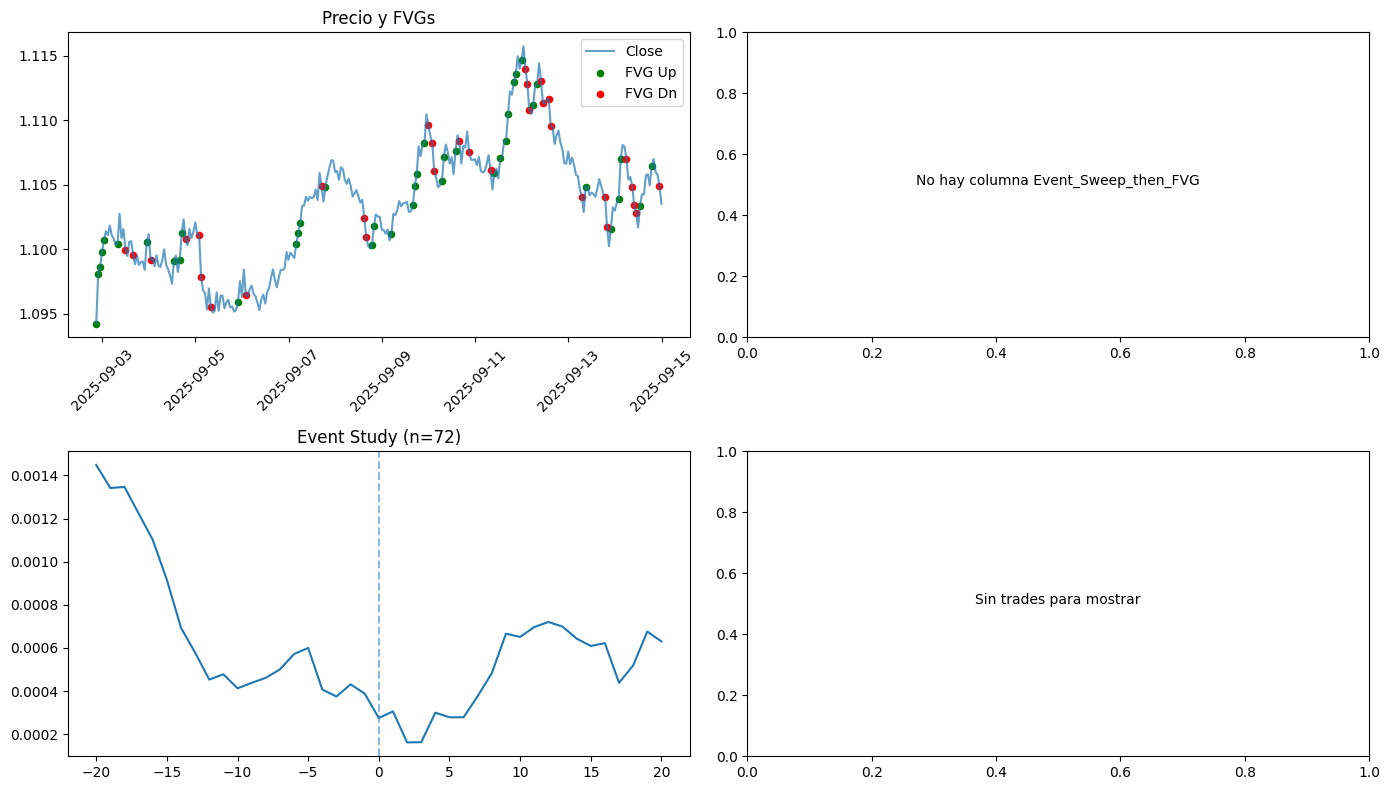

In [34]:
# --- Celda añadida: Plots robustos para FVG / eventos / event study ---
import matplotlib.pyplot as plt

ds = globals().get('enriched_data', globals().get('events_advanced', None))
if ds is None or ds.empty:
    print('No hay datos enriquecidos disponibles para graficar (enriched_data / events_advanced).')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax1 = axes[0,0]
    ax1.plot(ds.index, ds['Close'], label='Close', alpha=0.7)
    if 'FVG_Up' in ds.columns:
        ax1.scatter(ds.index[ds['FVG_Up']], ds['Close'][ds['FVG_Up']], s=20, label='FVG Up', color='green')
    if 'FVG_Dn' in ds.columns:
        ax1.scatter(ds.index[ds['FVG_Dn']], ds['Close'][ds['FVG_Dn']], s=20, label='FVG Dn', color='red')
    ax1.set_title('Precio y FVGs')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=45)

    ax2 = axes[0,1]
    if 'Event_Sweep_then_FVG' in ds.columns:
        try:
            summary = ds.groupby('InKZ')['Event_Sweep_then_FVG'].mean()
            summary.plot(kind='bar', ax=ax2)
            ax2.set_title('Tasa Sweep->FVG por InKZ')
        except Exception as e:
            ax2.text(0.5,0.5,f'Error al plotear: {e}', ha='center')
    else:
        ax2.text(0.5,0.5,'No hay columna Event_Sweep_then_FVG', ha='center')

    ax3 = axes[1,0]
    ev = globals().get('evs', None)
    if ev and 'mean_path' in ev:
        ax3.plot(ev['x'], ev['mean_path'], label='Reversión promedio')
        ax3.axvline(0, linestyle='--', alpha=0.5)
        ax3.set_title('Event Study (n={})'.format(ev.get('n_events', 0)))
    else:
        ax3.text(0.5,0.5,'No hay Event Study disponible', ha='center')

    ax4 = axes[1,1]
    trades = globals().get('enhanced_trades', None)
    if trades is not None and not trades.empty:
        trades['pnl'].hist(bins=20, ax=ax4)
        ax4.set_title('Distribución PnL')
    else:
        ax4.text(0.5,0.5,'Sin trades para mostrar', ha='center')

    plt.tight_layout()
    plt.show()

In [35]:
# --- Celda añadida: Backtest defensivo (simplificado) ---
import pandas as _pd
def advanced_backtest_defensive(d: pd.DataFrame, rr: float = 1.5, max_risk_per_trade: float = 0.01):
    if d is None or d.empty:
        print('Dataset vacío para backtest. Retornando DataFrame vacío.')
        return _pd.DataFrame()
    trades = []
    for i in range(len(d)-1):
        row = d.iloc[i]
        if row.get('Event_Sweep_then_FVG', False):
            entry = row['Close']
            exit_price = d.iloc[i+1]['Close']
            pnl = exit_price - entry
            trades.append({'time': d.index[i], 'entry': entry, 'exit': exit_price, 'pnl': pnl, 'killzone': row.get('Killzone','None')})
    return _pd.DataFrame(trades)

bt_input = globals().get('events_advanced', globals().get('enriched_data', None))
enhanced_trades = advanced_backtest_defensive(bt_input, rr=1.5, max_risk_per_trade=0.01)
print('Trades generados:', len(enhanced_trades) if enhanced_trades is not None else 0)
enhanced_trades.head()

Trades generados: 44


,time,entry,exit,pnl,killzone
0,2025-09-02 20:57:00-04:00,1.094230,1.098082,0.003853,None
1,2025-09-03 04:57:00-04:00,1.101065,1.100828,-0.000237,None
2,2025-09-03 10:57:00-04:00,1.101558,1.099946,-0.001613,None
3,2025-09-03 13:57:00-04:00,1.100563,1.100627,0.000064,NY_PM
4,2025-09-03 14:57:00-04:00,1.100627,1.099549,-0.001078,NY_PM


Total PnL: 0.0006227017605973106
Win rate: 0.5


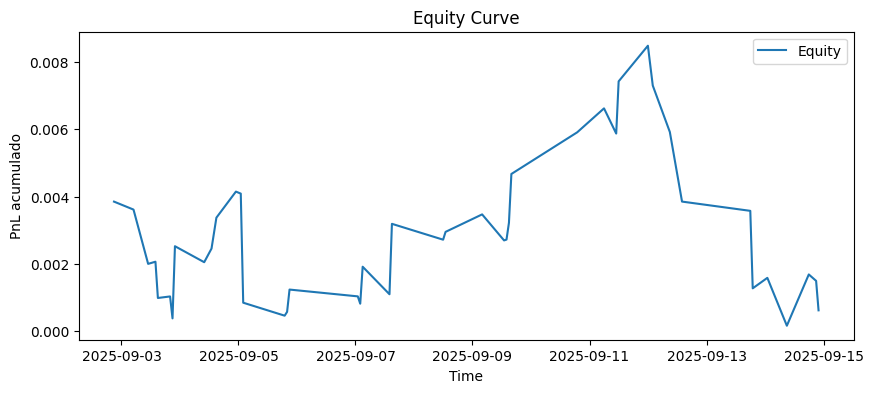

In [36]:
# --- Celda añadida: Análisis de performance y curva de equity ---
if 'enhanced_trades' not in globals() or enhanced_trades is None or enhanced_trades.empty:
    print('No hay trades para analizar.')
else:
    enhanced_trades = enhanced_trades.copy()
    enhanced_trades['pnl_cum'] = enhanced_trades['pnl'].cumsum()
    print('Total PnL:', enhanced_trades['pnl'].sum())
    print('Win rate:', (enhanced_trades['pnl']>0).mean())
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,4))
    plt.plot(enhanced_trades['time'], enhanced_trades['pnl_cum'], label='Equity')
    plt.title('Equity Curve')
    plt.xlabel('Time'); plt.ylabel('PnL acumulado')
    plt.legend(); plt.show()